In [2]:
import pandas as pd

df = pd.read_csv("dataset.csv")

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [6]:
X = df.drop("Churn", axis=1)
y = df["Churn"]


In [7]:
y = y.map({"No": 0, "Yes": 1})

In [8]:
y.value_counts()

,count
Churn,
0,5174
1,1869


In [9]:
X = X.drop("customerID", axis=1)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

print("Numeric:", list(numeric_features))
print("Categorical:", list(categorical_features))

Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [13]:
handle_unknown="ignore"

#B1 — Hyperparameter tuning

In [14]:
!pip install -q xgboost

In [15]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [16]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBClassifier(
            eval_metric="logloss",
            random_state=42
        )
    )
])

In [17]:
param_dist = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [3, 4, 6, 8]
}

In [18]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [19]:
import time

start = time.time()

search.fit(X_train, y_train)

xgb_tuning_time = time.time() - start

print("Tuning time:", xgb_tuning_time)
print("Best params:", search.best_params_)
print("Best CV F1:", search.best_score_)

Tuning time: 142.04899549484253
Best params: {'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.1}
Best CV F1: 0.5862422476526125


In [24]:
best_xgb = search.best_estimator_

print("Best parameters:", search.best_params_)
print("Best CV F1:", search.best_score_)

Best parameters: {'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.1}
Best CV F1: 0.5862422476526125


In [25]:
from sklearn.metrics import f1_score, roc_auc_score

y_pred_xgb = best_xgb.predict(X_test)
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

print("Test F1:", f1_score(y_test, y_pred_xgb))
print("Test ROC-AUC:", roc_auc_score(y_test, xgb_probs))

Test F1: 0.5773809523809523
Test ROC-AUC: 0.8422291973442868


#B2 — SVM Kernel Comparison
Linear SVM vs RBF SVM

In [27]:
from sklearn.svm import SVC

linear_svm = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        SVC(
            kernel="linear",
            C=1.0,
            probability=True,
            random_state=42
        )
    )
])

In [28]:
start = time.time()

linear_svm.fit(X_train, y_train)

linear_svm_time = time.time() - start

In [29]:
linear_pred = linear_svm.predict(X_test)

print(
    "Linear SVM F1:",
    f1_score(y_test, linear_pred)
)

Linear SVM F1: 0.5832147937411095


In [30]:
rbf_svm = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42
        )
    )
])

In [31]:
start = time.time()

rbf_svm.fit(X_train, y_train)

rbf_svm_time = time.time() - start

In [33]:
rbf_pred = rbf_svm.predict(X_test)

print(
    "RBF SVM F1:",
    f1_score(y_test, rbf_pred)
)

RBF SVM F1: 0.5570776255707762


In [34]:
rbf_probs = rbf_svm.predict_proba(X_test)[:, 1]

print(
    "RBF SVM ROC-AUC:",
    roc_auc_score(y_test, rbf_probs)
)

RBF SVM ROC-AUC: 0.8082474359967966


#B3 — Early Stopping

This is an important XGBoost concept.

In [35]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [39]:
X_tr_processed = preprocessor.fit_transform(X_tr)
X_val_processed = preprocessor.transform(X_val)

In [42]:
xgb_es = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    eval_metric="logloss",
    early_stopping_rounds=20,
    random_state=42
)

In [43]:
start = time.time()

xgb_es.fit(
    X_tr_processed,
    y_tr,
    eval_set=[(X_val_processed, y_val)],
    verbose=False
)

early_stop_time = time.time() - start

In [44]:
print(
    "Best iteration:",
    xgb_es.best_iteration
)

Best iteration: 110


#B4 — SVM comparison

compare:

Tuned XGBoost
vs
RBF SVM

In [45]:
start = time.time()

best_xgb.fit(X_train, y_train)

xgb_training_time = time.time() - start

print("XGBoost training time:", xgb_training_time)

XGBoost training time: 0.5929164886474609


In [46]:
start = time.time()

rbf_svm.fit(X_train, y_train)

svm_training_time = time.time() - start

print("SVM training time:", svm_training_time)

SVM training time: 15.692203998565674


In [47]:
start = time.time()

xgb_pred = best_xgb.predict(X_test)

xgb_inference_time = time.time() - start

In [48]:
start = time.time()

svm_pred = rbf_svm.predict(X_test)

svm_inference_time = time.time() - start

#C1 — Final hyperparameters

In [49]:
print(search.best_params_)

{'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.1}


#C2 — Calibration

In [53]:
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]
rbf_probs = rbf_svm.predict_proba(X_test)[:, 1]

In [54]:
from sklearn.calibration import calibration_curve

In [55]:
xgb_true, xgb_pred = calibration_curve(
    y_test,
    xgb_probs,
    n_bins=10,
    strategy="quantile"
)

print("XGBoost predicted probabilities:")
print(xgb_pred)

print("\nXGBoost actual churn rates:")
print(xgb_true)

XGBoost predicted probabilities:
[0.00747646 0.01921227 0.04055204 0.08117326 0.13869047 0.21962401
 0.32738037 0.44980554 0.58118452 0.78222786]

XGBoost actual churn rates:
[0.0070922  0.0212766  0.05673759 0.07801418 0.17730496 0.22857143
 0.36879433 0.39007092 0.55319149 0.77304965]


In [56]:
prob_true, prob_pred = calibration_curve(
    y_test,
    xgb_probs,
    n_bins=10,
    strategy="quantile"
)

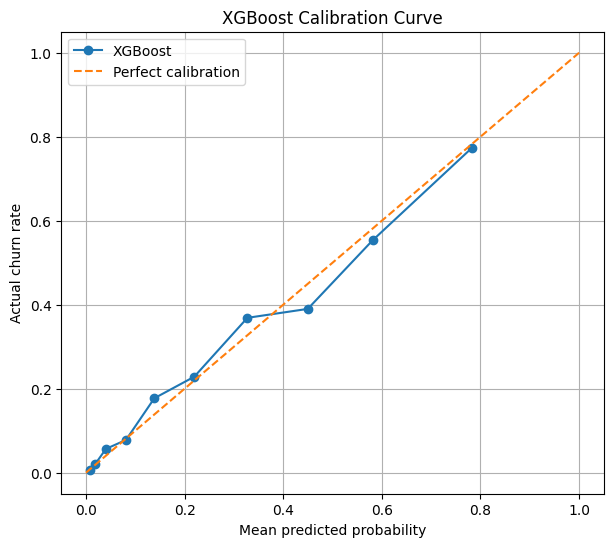

In [58]:
plt.figure(figsize=(7, 6))

plt.plot(
    xgb_pred,
    xgb_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Actual churn rate")
plt.title("XGBoost Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
import pandas as pd

calibration_table = pd.DataFrame({
    "Mean Predicted Probability": xgb_pred,
    "Actual Churn Rate": xgb_true
})

calibration_table["Difference"] = (
    calibration_table["Actual Churn Rate"]
    - calibration_table["Mean Predicted Probability"]
)

calibration_table

,Mean Predicted Probability,Actual Churn Rate,Difference
0,0.007476,0.007092,-0.000384
1,0.019212,0.021277,0.002064
2,0.040552,0.056738,0.016186
3,0.081173,0.078014,-0.003159
4,0.138690,0.177305,0.038614
5,0.219624,0.228571,0.008947
6,0.327380,0.368794,0.041414
7,0.449806,0.390071,-0.059735
8,0.581185,0.553191,-0.027993
9,0.782228,0.773050,-0.009178


In [60]:
svm_true, svm_pred = calibration_curve(
    y_test,
    rbf_probs,
    n_bins=10,
    strategy="quantile"
)

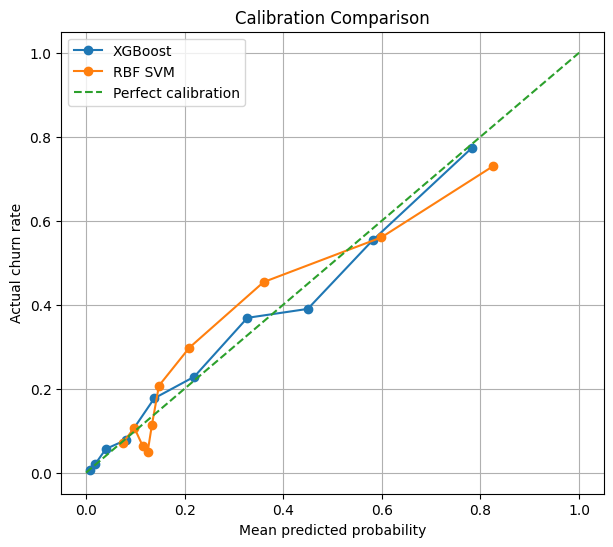

In [61]:
plt.figure(figsize=(7, 6))

plt.plot(
    xgb_pred,
    xgb_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    svm_pred,
    svm_true,
    marker="o",
    label="RBF SVM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Actual churn rate")
plt.title("Calibration Comparison")
plt.legend()
plt.grid(True)
plt.show()

#C3 — Compare calibration for both models

In [62]:
xgb_calibration_table = pd.DataFrame({
    "Model": "XGBoost",
    "Mean Predicted Probability": xgb_pred,
    "Actual Churn Rate": xgb_true
})

svm_calibration_table = pd.DataFrame({
    "Model": "RBF SVM",
    "Mean Predicted Probability": svm_pred,
    "Actual Churn Rate": svm_true
})

calibration_table = pd.concat(
    [xgb_calibration_table, svm_calibration_table],
    ignore_index=True
)

calibration_table

,Model,Mean Predicted Probability,Actual Churn Rate
0,XGBoost,0.007476,0.007092
1,XGBoost,0.019212,0.021277
2,XGBoost,0.040552,0.056738
3,XGBoost,0.081173,0.078014
4,XGBoost,0.138690,0.177305
5,XGBoost,0.219624,0.228571
6,XGBoost,0.327380,0.368794
7,XGBoost,0.449806,0.390071
8,XGBoost,0.581185,0.553191
9,XGBoost,0.782228,0.773050


In [63]:
from sklearn.metrics import brier_score_loss

xgb_brier = brier_score_loss(
    y_test,
    xgb_probs
)

svm_brier = brier_score_loss(
    y_test,
    rbf_probs
)

print("XGBoost Brier Score:", xgb_brier)
print("RBF SVM Brier Score:", svm_brier)

XGBoost Brier Score: 0.13653375971780643
RBF SVM Brier Score: 0.14597280275004704


In [64]:
import time

# XGBoost probability inference time
start = time.perf_counter()
_ = best_xgb.predict_proba(X_test)
xgb_inference_time = time.perf_counter() - start

# RBF SVM probability inference time
start = time.perf_counter()
_ = rbf_svm.predict_proba(X_test)
svm_inference_time = time.perf_counter() - start

print("XGBoost inference time:", xgb_inference_time, "seconds")
print("RBF SVM inference time:", svm_inference_time, "seconds")

print("XGBoost ms/customer:",
      xgb_inference_time / len(X_test) * 1000)

print("RBF SVM ms/customer:",
      svm_inference_time / len(X_test) * 1000)

XGBoost inference time: 0.04377740599966273 seconds
RBF SVM inference time: 0.560725623000053 seconds
XGBoost ms/customer: 0.031069841021762055
RBF SVM ms/customer: 0.3979599879347431
